# Özel (Custom) Transformer

In [1]:
import pandas as pd
import seaborn as sns

👉 Bu veri setini kullanacağız:

In [2]:
data = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/custom_transformer_data.csv")
data.head()

,customer_state,seller_state,product_weight_g,product_length_cm,product_height_cm,product_width_cm,days_until_delivery
0,RJ,SP,1825,53,10,40,9
1,RJ,SP,700,65,18,28,9
2,RJ,SP,1825,53,10,40,11
3,RJ,SP,1825,53,10,40,12
4,RJ,SP,1825,53,10,40,14


- Veri setindeki her bir gözlem, bir ürünün bir `seller_state`’ten bir `customer_state`’e teslim edilmesini temsil eder.  
- Diğer sütunlar, her bir ürünün paketleme özelliklerini açıklar.

🎯 Hedef, sipariş ile teslimat arasındaki gün sayısıdır.

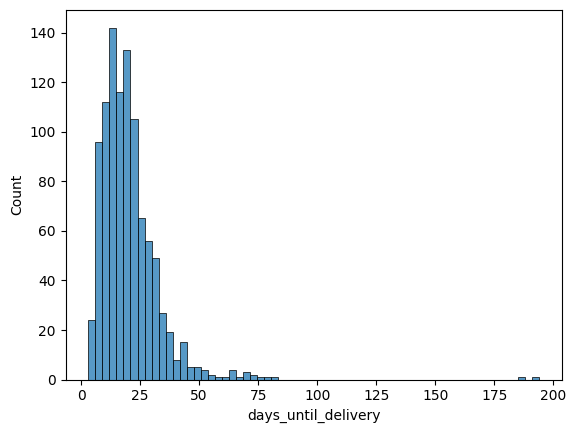

In [3]:
#  Hedefi kontrol et
sns.histplot(data.days_until_delivery);

## 1. Pipeline

👉 `pipe` adlı bir scikit-learn pipeline oluşturun:

- Boyut feature’larından (`dimensions`) bir `volume` feature’ı türetin
- Eğitim için orijinal ürün boyut feature’larını koruyun
- Tüm sayısal feature’ları ölçekleyin
- Kategorik feature’ları encode edin
- Varsayılan ayarlarla bir `Ridge` regresyon estimator’ı ekleyin

**Not:** Bu challenge için holdout yöntemi yok sayılacaktır; yani `train_test_split` kullanmanıza gerek yoktur!

<details><summary><strong>İpuçları</strong></summary>

- Ön işlenmiş feature matrisinizi oluşturmanın birçok yolu vardır (`ColumnTransformer` ve/veya `FeatureUnion` kullanarak). 
    
- Dönüştürülmüş feature matrisiniz garip görünüyorsa, bunun nedeni `OneHotEncoder(sparse_output=True)` varsayılan davranışıyla matrisin "sparse" olarak saklanması olabilir. Bunu tekrar dense bir matrise çevirmek için `.todense()` kullanın.

- Varsayılan NumPy array çıktısı yerine sütun adlarıyla birlikte bir Pandas DataFrame çıktısı almak için, final pipeline’ınızda `.set_output(transform='pandas')` kullanın. (Bunu her bir transformer üzerinde tek tek ayarlamanıza gerek yoktur. Pipeline üzerinde ayarlarsanız, bunu alt aşamalara da aktarır.)

</details>

<br>

<details><summary><strong>Daha fazla ipucu: adım adım yönlendirme</strong> (yalnızca takılırsanız açın)</summary>

Pipeline’ı oluşturmanın en kolay yolu budur.

1. Uzunluk, genişlik ve yükseklik verildiğinde hacmi hesaplayan bir python `function` oluşturun.
2. Aşağıdakilerden oluşan bir hacim hesaplayıcı pipeline oluşturun:
   1. Python `function`’ınızı kullanan bir `FunctionTransformer`.
   1. Ardından bir scaler
3. `ColumnTransformer` kullanarak tam bir preprocessor oluşturun:
   - Orijinal sayısal feature’lar için bir scaler.
   - Kategorik feature’lar için bir encoder.
   - Uzunluk, genişlik ve yükseklik feature’ları için hacim hesaplayıcı pipeline’ınız.
4. Son olarak, tam preprocessor’ınızı ve ardından `Ridge` modelini içeren bir pipeline oluşturun.

</details>

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import Ridge

# X ve y
X = data.drop(columns=["days_until_delivery"])
y = data["days_until_delivery"]

# sütunlar
numeric_features = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

categorical_features = [
    "seller_state",
    "customer_state"
]

dimension_features = [
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

# custom transformer
def compute_volume(df):
    volume = (
        df["product_length_cm"]
        * df["product_height_cm"]
        * df["product_width_cm"]
    )
    return pd.DataFrame({"volume": volume}, index=df.index)

volume_pipeline = Pipeline([
    ("volume_creator", FunctionTransformer(compute_volume, validate=False)),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("volume", volume_pipeline, dimension_features)
])

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("ridge", Ridge())
])

#### 🧪  pipe'ını test et

In [6]:
from nbresult import ChallengeResult

pipe_test = pipe

# Çökmediğini kontrol edin
assert pipe_test.fit(X, y)

result = ChallengeResult(
    'pipe',
    shape = pipe_test[:-1].fit_transform(X).shape
)

result.write()
print(result.check())

## 2. Train ve Predict

👇 `data`’nın tüm eğitim veri setiniz olduğunu varsayalım.

- Bu veri seti üzerinde pipeline’ınızı `cross_validate` edin (❗️düşük $R^2$ skorları beklenmektedir)
- Şimdi de yeni bir sipariş aldığınızı varsayın: `new_data`  
  Teslimat süresini tahmin edin ve sonucu `prediction` adlı değişkende saklayın

In [7]:
new_data = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/custom_transformer_new_order.csv")
new_data

,customer_state,seller_state,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,RJ,SP,1825,53,10,40


In [13]:
from sklearn.model_selection import cross_validate

# cross validation
cv_results = cross_validate(
    pipe,
    X,
    y,
    cv=5,
    scoring=["r2", "neg_root_mean_squared_error"]
)

# modeli tüm veri ile eğit
pipe.fit(X, y)

# yeni sipariş için tahmin
prediction = pipe.predict(new_data)[0]

prediction

np.float64(20.685690224161306)

In [14]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'prediction',
    prediction = prediction
)

result.write()
print(result.check())


In [9]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'prediction',
    prediction = prediction
)

result.write()
print(result.check())


NameError: name 'prediction' is not defined

In [10]:
from sklearn.model_selection import cross_validate

# cross validation
cv_results = cross_validate(
    pipe,
    X,
    y,
    cv=5,
    scoring=["r2", "neg_root_mean_squared_error"]
)

cv_results

{'fit_time': array([0.21908259, 0.03453326, 0.03699565, 0.0504365 , 0.52424097]),
 'score_time': array([0.02304626, 0.02382374, 0.0231173 , 0.02321839, 0.0195055 ]),
 'test_r2': array([0.14022618, 0.12917382, 0.10896041, 0.01263727, 0.23261099]),
 'test_neg_root_mean_squared_error': array([ -9.33866378,  -8.2644148 , -16.2852394 , -16.86973485,
        -10.13690024])}

🏁 Tebrikler. Not defterinizi eklemeyi, kaydetmeyi ve göndermeyi unutmayın.

NameError: name 'prediction' is not defined